In [30]:
# CLEAN CONSENSUS METABOLITE PANEL PIPELINE

import os, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report

# =========================
# SETTINGS
# =========================

BASE = "../.."
META_PATH = f"{BASE}/data/metadata/Metadata_061523.csv"
METAB_PATH = f"{BASE}/data/metabolomics/Metabolomics_maaslined_norun.csv"

RANDOM_STATE = 42
OUT_DIR = f"{BASE}/output/consensus_metabolite_panel_clean"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# LOAD + CLEAN DATA
# =========================

meta_raw = pd.read_csv(META_PATH)
metab_raw = pd.read_csv(METAB_PATH)

metab = (
    metab_raw
    .set_index("Unnamed: 0")
    .T
    .reset_index()
    .rename(columns={"index": "sample_id"})
)

metab["participant_id"] = metab["sample_id"].str.replace(r"_tp\d+$", "", regex=True)
metab["timepoint"] = metab["sample_id"].str.extract(r"_tp(\d+)")

tp1 = metab[metab["timepoint"] == "1"].copy()

meta_raw["participant_id"] = meta_raw["samples_id"].astype(str)
meta_tp1 = meta_raw[meta_raw["timepoints"] == "tp1"].copy()

df = tp1.merge(meta_tp1, on="participant_id", how="inner")

y = df["study_ptorhc"].map({"MECFS": 1, "Control": 0})

metadata_cols = list(meta_raw.columns) + ["sample_id", "participant_id", "timepoint"]
feature_cols = [c for c in df.columns if c not in metadata_cols]

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.loc[:, X.notna().all()]

print("Full X:", X.shape)
print("Class counts:", y.value_counts().to_dict())

# =========================
# FREEZE HELD-OUT TEST SET
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, y_train.value_counts().to_dict())
print("Test:", X_test.shape, y_test.value_counts().to_dict())

# =========================
# CONSENSUS FEATURE SELECTION
# repeated CV LASSO on TRAIN ONLY
# =========================

C_GRID = [0.01, 0.03, 0.06, 0.1, 0.3]
N_REPEATS = 20
N_SPLITS = 5

counts = pd.Series(0, index=X_train.columns, dtype=int)

for repeat in range(N_REPEATS):
    cv = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE + repeat
    )
    
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        
        for C in C_GRID:
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("lasso", LogisticRegression(
                    penalty="l1",
                    solver="liblinear",
                    C=C,
                    max_iter=5000,
                    random_state=RANDOM_STATE
                ))
            ])
            
            model.fit(X_tr, y_tr)
            coefs = model.named_steps["lasso"].coef_[0]
            selected = X_train.columns[coefs != 0]
            counts[selected] += 1

total_runs = N_REPEATS * N_SPLITS * len(C_GRID)

consensus_df = pd.DataFrame({
    "metabolite": counts.index,
    "count": counts.values,
    "frequency": counts.values / total_runs
}).sort_values(["count", "metabolite"], ascending=[False, True]).reset_index(drop=True)

consensus_df["rank"] = consensus_df.index + 1

print("\n===== TOP 40 CONSENSUS METABOLITES =====")
display(consensus_df.head(40))

consensus_df.to_csv(f"{OUT_DIR}/consensus_feature_frequencies.csv", index=False)

# =========================
# BUILD PANELS FROM CONSENSUS RANKING
# =========================

ordered_features = consensus_df["metabolite"].tolist()
panel_sizes = [3, 5, 8, 10, 15]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []

for k in panel_sizes:
    feats = ordered_features[:k]
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            C=1.0,
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])
    
    aucs = cross_val_score(
        model,
        X_train[feats],
        y_train,
        cv=cv,
        scoring="roc_auc"
    )
    
    results.append({
        "panel_size": k,
        "mean_train_cv_auc": aucs.mean(),
        "std_train_cv_auc": aucs.std(),
        "features": feats
    })

results_df = pd.DataFrame(results)

print("\n===== TRAIN-ONLY PANEL CV RESULTS =====")
display(results_df[["panel_size", "mean_train_cv_auc", "std_train_cv_auc"]])

results_df.to_csv(f"{OUT_DIR}/panel_cv_results.csv", index=False)

# =========================
# LOCK FINAL PANEL
# smallest panel within 0.01 AUC of best
# =========================

best_auc = results_df["mean_train_cv_auc"].max()
eligible = results_df[results_df["mean_train_cv_auc"] >= best_auc - 0.01]
chosen = eligible.sort_values(["panel_size", "mean_train_cv_auc"], ascending=[True, False]).iloc[0]

FINAL_FEATURES = chosen["features"]

print("\n===== LOCKED FINAL PANEL =====")
print("Panel size:", chosen["panel_size"])
print("Train CV AUC:", chosen["mean_train_cv_auc"], "+/-", chosen["std_train_cv_auc"])

for f in FINAL_FEATURES:
    print("-", f)

# =========================
# HELD-OUT TEST EVALUATION ONCE
# =========================

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        C=1.0,
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

final_model.fit(X_train[FINAL_FEATURES], y_train)

test_probs = final_model.predict_proba(X_test[FINAL_FEATURES])[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, test_probs)
test_acc = accuracy_score(y_test, test_preds)
test_bal_acc = balanced_accuracy_score(y_test, test_preds)
cm = confusion_matrix(y_test, test_preds)

print("\n===== HELD-OUT TEST PERFORMANCE =====")
print("AUC:", test_auc)
print("Accuracy:", test_acc)
print("Balanced accuracy:", test_bal_acc)
print("Confusion matrix:")
print(cm)
print("\nClassification report:")
print(classification_report(y_test, test_preds))

# =========================
# COEFFICIENTS + SAVE
# =========================

coef = pd.Series(
    final_model.named_steps["logreg"].coef_[0],
    index=FINAL_FEATURES
).sort_values(key=abs, ascending=False)

intercept = final_model.named_steps["logreg"].intercept_[0]

print("\n===== FINAL COEFFICIENTS =====")
print("Intercept:", intercept)
display(coef)

pd.Series(FINAL_FEATURES, name="metabolite").to_csv(
    f"{OUT_DIR}/LOCKED_FINAL_PANEL.csv",
    index=False
)

coef.to_csv(f"{OUT_DIR}/LOCKED_FINAL_PANEL_COEFFICIENTS.csv")

summary = pd.DataFrame([{
    "panel_size": chosen["panel_size"],
    "train_cv_auc_mean": chosen["mean_train_cv_auc"],
    "train_cv_auc_std": chosen["std_train_cv_auc"],
    "heldout_test_auc": test_auc,
    "heldout_test_accuracy": test_acc,
    "heldout_test_balanced_accuracy": test_bal_acc,
    "features": " | ".join(FINAL_FEATURES)
}])

summary.to_csv(f"{OUT_DIR}/LOCKED_FINAL_PANEL_SUMMARY.csv", index=False)

print("\nSaved to:", OUT_DIR)

Full X: (214, 876)
Class counts: {1: 135, 0: 79}
Train: (171, 876) {1: 108, 0: 63}
Test: (43, 876) {1: 27, 0: 16}

===== TOP 40 CONSENSUS METABOLITES =====


,metabolite,count,frequency,rank
0,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),254,0.508,1
1,N-acetylglutamate,251,0.502,2
2,N4-acetylcytidine,233,0.466,3
3,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",232,0.464,4
4,1-methylurate,228,0.456,5
5,N-palmitoyl-sphingosine (d18:1/16:0),228,0.456,6
6,3-(4-hydroxyphenyl)lactate,214,0.428,7
7,N-acetylglucosamine/N-acetylgalactosamine,173,0.346,8
8,vanillylmandelate (VMA),156,0.312,9
9,4-vinylguaiacol sulfate,149,0.298,10



===== TRAIN-ONLY PANEL CV RESULTS =====


,panel_size,mean_train_cv_auc,std_train_cv_auc
0,3,0.784008,0.096590
1,5,0.837895,0.057929
2,8,0.862279,0.057165
3,10,0.885922,0.070457
4,15,0.918640,0.037366



===== LOCKED FINAL PANEL =====
Panel size: 15
Train CV AUC: 0.9186396936396937 +/- 0.037365820318476364
- 1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)
- N-acetylglutamate
- N4-acetylcytidine
- sphingomyelin (d18:1/24:1, d18:2/24:0)*
- 1-methylurate
- N-palmitoyl-sphingosine (d18:1/16:0)
- 3-(4-hydroxyphenyl)lactate
- N-acetylglucosamine/N-acetylgalactosamine
- vanillylmandelate (VMA)
- 4-vinylguaiacol sulfate
- glycodeoxycholate 3-sulfate
- N-acetylhistidine
- X-18886
- branched-chain, straight-chain, or cyclopropyl 10:1 fatty acid (1)*
- X-13866

===== HELD-OUT TEST PERFORMANCE =====
AUC: 0.8587962962962963
Accuracy: 0.7674418604651163
Balanced accuracy: 0.7384259259259259
Confusion matrix:
[[10  6]
 [ 4 23]]

Classification report:
              precision    recall  f1-score   support

           0       0.71      0.62      0.67        16
           1       0.79      0.85      0.82        27

    accuracy                           0.77        43
   macro avg       0.75      0.74    

N4-acetylcytidine                                                      0.854472
vanillylmandelate (VMA)                                               -0.827180
3-(4-hydroxyphenyl)lactate                                            -0.790719
N-acetylglucosamine/N-acetylgalactosamine                              0.787882
1-methylurate                                                         -0.710956
N-acetylglutamate                                                      0.709466
X-13866                                                                0.600591
X-18886                                                                0.591037
N-acetylhistidine                                                      0.586182
N-palmitoyl-sphingosine (d18:1/16:0)                                   0.571310
4-vinylguaiacol sulfate                                               -0.503879
branched-chain, straight-chain, or cyclopropyl 10:1 fatty acid (1)*   -0.493161
1-stearoyl-2-docosahexaenoyl-GPC (18:0/2


Saved to: ../../output/consensus_metabolite_panel_clean


In [31]:
# =========================
# SELECT BEST TRADEOFF PANEL
# =========================

tradeoff_df = results_df.copy()

# Sort by panel size
tradeoff_df = tradeoff_df.sort_values("panel_size").reset_index(drop=True)

# Calculate gains from adding more metabolites
tradeoff_df["auc_gain_from_previous"] = tradeoff_df["mean_train_cv_auc"].diff()
tradeoff_df["features_added"] = tradeoff_df["panel_size"].diff()
tradeoff_df["auc_gain_per_added_feature"] = (
    tradeoff_df["auc_gain_from_previous"] / tradeoff_df["features_added"]
)

# Define best AUC
best_auc = tradeoff_df["mean_train_cv_auc"].max()

# Rule:
# choose the smallest panel with CV AUC at least 95% of best AUC
# AND mean CV AUC >= 0.85 if possible
tradeoff_df["pct_of_best_auc"] = tradeoff_df["mean_train_cv_auc"] / best_auc

eligible = tradeoff_df[
    (tradeoff_df["pct_of_best_auc"] >= 0.95) &
    (tradeoff_df["mean_train_cv_auc"] >= 0.85)
].copy()

if len(eligible) == 0:
    chosen_tradeoff = tradeoff_df.sort_values(
        ["mean_train_cv_auc", "panel_size"],
        ascending=[False, True]
    ).iloc[0]
else:
    chosen_tradeoff = eligible.sort_values(
        ["panel_size", "mean_train_cv_auc"],
        ascending=[True, False]
    ).iloc[0]

TRADEOFF_PANEL_SIZE = int(chosen_tradeoff["panel_size"])
TRADEOFF_FEATURES = chosen_tradeoff["features"]

print("===== PANEL TRADEOFF TABLE =====")
display(
    tradeoff_df[
        [
            "panel_size",
            "mean_train_cv_auc",
            "std_train_cv_auc",
            "auc_gain_from_previous",
            "auc_gain_per_added_feature",
            "pct_of_best_auc"
        ]
    ]
)

print("\n===== SELECTED TRADEOFF PANEL =====")
print("Panel size:", TRADEOFF_PANEL_SIZE)
print("CV AUC:", chosen_tradeoff["mean_train_cv_auc"], "+/-", chosen_tradeoff["std_train_cv_auc"])
print("Percent of best AUC:", chosen_tradeoff["pct_of_best_auc"])

print("\nFeatures:")
for f in TRADEOFF_FEATURES:
    print("-", f)

===== PANEL TRADEOFF TABLE =====


,panel_size,mean_train_cv_auc,std_train_cv_auc,auc_gain_from_previous,auc_gain_per_added_feature,pct_of_best_auc
0,3,0.784008,0.096590,NaN,NaN,0.853444
1,5,0.837895,0.057929,0.053888,0.026944,0.912105
2,8,0.862279,0.057165,0.024384,0.008128,0.938648
3,10,0.885922,0.070457,0.023643,0.011822,0.964385
4,15,0.918640,0.037366,0.032717,0.006543,1.000000



===== SELECTED TRADEOFF PANEL =====
Panel size: 10
CV AUC: 0.8859224109224109 +/- 0.07045693923495479
Percent of best AUC: 0.9643850761688129

Features:
- 1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)
- N-acetylglutamate
- N4-acetylcytidine
- sphingomyelin (d18:1/24:1, d18:2/24:0)*
- 1-methylurate
- N-palmitoyl-sphingosine (d18:1/16:0)
- 3-(4-hydroxyphenyl)lactate
- N-acetylglucosamine/N-acetylgalactosamine
- vanillylmandelate (VMA)
- 4-vinylguaiacol sulfate


In [32]:
# =========================
# HELD-OUT TEST EVALUATION: 10-METABOLITE TRADEOFF PANEL
# =========================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

tradeoff_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        C=1.0,
        max_iter=5000,
        random_state=42
    ))
])

tradeoff_model.fit(X_train[TRADEOFF_FEATURES], y_train)

test_probs = tradeoff_model.predict_proba(X_test[TRADEOFF_FEATURES])[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

print("===== 10-PANEL HELD-OUT TEST PERFORMANCE =====")
print("AUC:", roc_auc_score(y_test, test_probs))
print("Accuracy:", accuracy_score(y_test, test_preds))
print("Balanced accuracy:", balanced_accuracy_score(y_test, test_preds))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, test_preds))

print("\nClassification report:")
print(classification_report(y_test, test_preds))

coef_10 = pd.Series(
    tradeoff_model.named_steps["logreg"].coef_[0],
    index=TRADEOFF_FEATURES
).sort_values(key=abs, ascending=False)

intercept_10 = tradeoff_model.named_steps["logreg"].intercept_[0]

print("\nIntercept:", intercept_10)
print("\nCoefficients:")
display(coef_10)

===== 10-PANEL HELD-OUT TEST PERFORMANCE =====
AUC: 0.8587962962962963
Accuracy: 0.7906976744186046
Balanced accuracy: 0.7569444444444444

Confusion matrix:
[[10  6]
 [ 3 24]]

Classification report:
              precision    recall  f1-score   support

           0       0.77      0.62      0.69        16
           1       0.80      0.89      0.84        27

    accuracy                           0.79        43
   macro avg       0.78      0.76      0.77        43
weighted avg       0.79      0.79      0.79        43


Intercept: 0.8662932130950685

Coefficients:


N-acetylglutamate                               0.893792
N4-acetylcytidine                               0.820613
3-(4-hydroxyphenyl)lactate                     -0.733765
vanillylmandelate (VMA)                        -0.723152
N-palmitoyl-sphingosine (d18:1/16:0)            0.565130
1-methylurate                                  -0.504033
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)    0.476416
sphingomyelin (d18:1/24:1, d18:2/24:0)*         0.475558
N-acetylglucosamine/N-acetylgalactosamine       0.436356
4-vinylguaiacol sulfate                        -0.252933
dtype: float64

,panel_size,mean_repeated_split_auc,median_repeated_split_auc,std_repeated_split_auc,min_repeated_split_auc,max_repeated_split_auc,heldout_seed42_auc,features
0,10,0.864468,0.863426,0.05668,0.666667,0.972222,0.858796,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6) |...


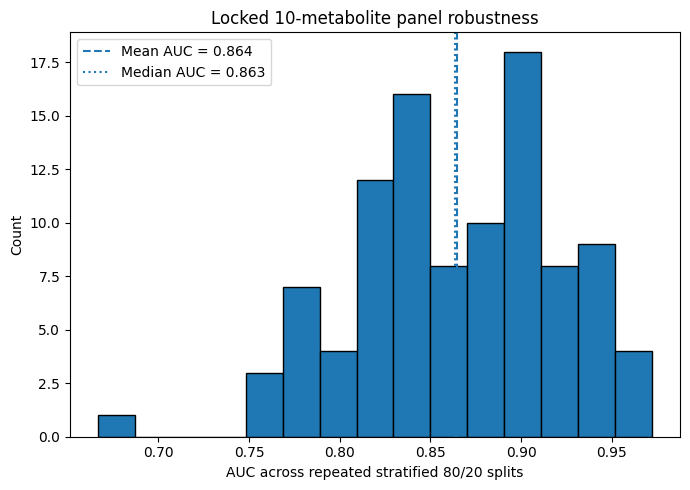

Locked 10-panel saved.
Repeated split AUC mean: 0.8644675925925925
Repeated split AUC median: 0.8634259259259259
Repeated split AUC std: 0.0566797663613791
Saved to: ../../output/consensus_metabolite_panel_clean


In [33]:
# =========================
# SAVE LOCKED 10-PANEL + ROBUSTNESS EVALUATION
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

LOCKED_PANEL = TRADEOFF_FEATURES
OUT_DIR = "../../output/consensus_metabolite_panel_clean"
os.makedirs(OUT_DIR, exist_ok=True)

# Save locked panel
pd.Series(LOCKED_PANEL, name="metabolite").to_csv(
    f"{OUT_DIR}/LOCKED_10_PANEL.csv",
    index=False
)

# Save coefficients
coef_10.to_csv(f"{OUT_DIR}/LOCKED_10_PANEL_COEFFICIENTS.csv")

# Repeated split robustness: fixed locked panel only
aucs = []

for seed in range(100):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=seed
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            C=1.0,
            max_iter=5000,
            random_state=seed
        ))
    ])

    model.fit(X_tr[LOCKED_PANEL], y_tr)
    probs = model.predict_proba(X_te[LOCKED_PANEL])[:, 1]
    aucs.append(roc_auc_score(y_te, probs))

robustness_summary = pd.DataFrame([{
    "panel_size": len(LOCKED_PANEL),
    "mean_repeated_split_auc": np.mean(aucs),
    "median_repeated_split_auc": np.median(aucs),
    "std_repeated_split_auc": np.std(aucs),
    "min_repeated_split_auc": np.min(aucs),
    "max_repeated_split_auc": np.max(aucs),
    "heldout_seed42_auc": roc_auc_score(y_test, test_probs),
    "features": " | ".join(LOCKED_PANEL)
}])

display(robustness_summary)

robustness_summary.to_csv(
    f"{OUT_DIR}/LOCKED_10_PANEL_REPEATED_SPLIT_ROBUSTNESS.csv",
    index=False
)

# Plot AUC distribution
plt.figure(figsize=(7, 5))
plt.hist(aucs, bins=15, edgecolor="black")
plt.axvline(np.mean(aucs), linestyle="--", label=f"Mean AUC = {np.mean(aucs):.3f}")
plt.axvline(np.median(aucs), linestyle=":", label=f"Median AUC = {np.median(aucs):.3f}")
plt.xlabel("AUC across repeated stratified 80/20 splits")
plt.ylabel("Count")
plt.title("Locked 10-metabolite panel robustness")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/LOCKED_10_PANEL_AUC_DISTRIBUTION.png", dpi=300)
plt.show()

print("Locked 10-panel saved.")
print("Repeated split AUC mean:", np.mean(aucs))
print("Repeated split AUC median:", np.median(aucs))
print("Repeated split AUC std:", np.std(aucs))
print("Saved to:", OUT_DIR)

Real AUC: 0.8530864197530864
Permutation p-value: 0.0


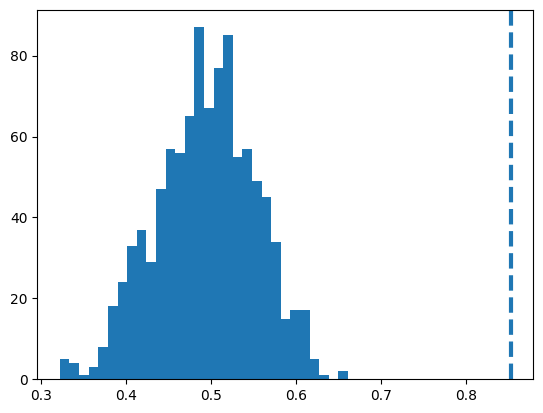

In [34]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

real_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

real_auc = cross_val_score(
    real_model,
    X[LOCKED_PANEL],
    y,
    cv=5,
    scoring="roc_auc"
).mean()

perm_aucs = []

for i in range(1000):

    y_perm = np.random.permutation(y)

    auc = cross_val_score(
        real_model,
        X[LOCKED_PANEL],
        y_perm,
        cv=5,
        scoring="roc_auc"
    ).mean()

    perm_aucs.append(auc)

perm_aucs = np.array(perm_aucs)

p_value = np.mean(perm_aucs >= real_auc)

print("Real AUC:", real_auc)
print("Permutation p-value:", p_value)

plt.hist(perm_aucs, bins=30)
plt.axvline(real_auc, linestyle="--", linewidth=3)
plt.show()

In [35]:
from sklearn.metrics import roc_auc_score

boot_aucs = []

rng = np.random.default_rng(42)

for _ in range(2000):

    idx = rng.choice(
        len(y_test),
        size=len(y_test),
        replace=True
    )

    if len(np.unique(y_test.iloc[idx])) < 2:
        continue

    auc = roc_auc_score(
        y_test.iloc[idx],
        test_probs[idx]
    )

    boot_aucs.append(auc)

ci_lower = np.percentile(boot_aucs, 2.5)
ci_upper = np.percentile(boot_aucs, 97.5)

print("Test AUC:", roc_auc_score(y_test, test_probs))
print("95% CI:", ci_lower, "-", ci_upper)

Test AUC: 0.8587962962962963
95% CI: 0.728475935828877 - 0.9538461538461538


In [36]:
from scipy.stats import mannwhitneyu

results = []

for m in TRADEOFF_FEATURES:

    case = X.loc[y == 1, m]
    ctrl = X.loc[y == 0, m]

    stat, p = mannwhitneyu(case, ctrl)

    results.append({
        "metabolite": m,
        "p": p
    })

pd.DataFrame(results).sort_values("p")

,metabolite,p
6,3-(4-hydroxyphenyl)lactate,0.000001
3,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",0.000016
5,N-palmitoyl-sphingosine (d18:1/16:0),0.000022
0,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),0.000025
2,N4-acetylcytidine,0.000063
1,N-acetylglutamate,0.000116
4,1-methylurate,0.000160
9,4-vinylguaiacol sulfate,0.000202
8,vanillylmandelate (VMA),0.000496
7,N-acetylglucosamine/N-acetylgalactosamine,0.001607


In [37]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import numpy as np

def cohens_d(x, y):

    nx, ny = len(x), len(y)

    pooled = np.sqrt(
        (
            (nx - 1) * x.var(ddof=1)
            + (ny - 1) * y.var(ddof=1)
        )
        / (nx + ny - 2)
    )

    return (x.mean() - y.mean()) / pooled

rows = []

for m in TRADEOFF_FEATURES:

    case = X.loc[y == 1, m]
    ctrl = X.loc[y == 0, m]

    _, p = mannwhitneyu(case, ctrl)

    rows.append({
        "metabolite": m,
        "p": p,
        "cohens_d": cohens_d(case, ctrl)
    })

stats_df = pd.DataFrame(rows)

stats_df["fdr"] = multipletests(
    stats_df["p"],
    method="fdr_bh"
)[1]

stats_df = stats_df.sort_values("fdr")

display(stats_df)

,metabolite,p,cohens_d,fdr
6,3-(4-hydroxyphenyl)lactate,0.000001,-0.607446,0.000012
0,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),0.000025,0.604367,0.000062
3,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",0.000016,0.620477,0.000062
5,N-palmitoyl-sphingosine (d18:1/16:0),0.000022,0.627788,0.000062
2,N4-acetylcytidine,0.000063,0.559763,0.000126
1,N-acetylglutamate,0.000116,0.636926,0.000193
4,1-methylurate,0.000160,-0.532764,0.000228
9,4-vinylguaiacol sulfate,0.000202,-0.484969,0.000252
8,vanillylmandelate (VMA),0.000496,-0.482851,0.000551
7,N-acetylglucosamine/N-acetylgalactosamine,0.001607,0.417861,0.001607


In [38]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_importance = pd.DataFrame({
    "metabolite": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

display(rf_importance.head(30))

,metabolite,importance
20,3-(4-hydroxyphenyl)lactate,0.009605
334,beta-cryptoxanthin,0.009399
739,X-11847,0.009283
516,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),0.008480
259,N4-acetylcytidine,0.008264
737,X-11795,0.007863
380,5-(galactosylhydroxy)-lysine,0.007635
465,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",0.007418
138,N-acetylglutamate,0.006762
740,X-11849,0.006398


In [39]:
rf_top20 = set(rf_importance.head(20)["metabolite"])

locked_overlap = [
    m for m in TRADEOFF_FEATURES
    if m in rf_top20
]

print("Locked panel metabolites in RF top 20:")
print(len(locked_overlap), "/", len(TRADEOFF_FEATURES))

for m in locked_overlap:
    print("-", m)

Locked panel metabolites in RF top 20:
6 / 10
- 1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)
- N-acetylglutamate
- N4-acetylcytidine
- sphingomyelin (d18:1/24:1, d18:2/24:0)*
- 1-methylurate
- 3-(4-hydroxyphenyl)lactate


In [40]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_df = pd.DataFrame({
    "metabolite": X_train.columns,
    "mi": mi
}).sort_values("mi", ascending=False)

display(mi_df.head(30))

,metabolite,mi
353,"androstenediol (3beta,17beta) monosulfate (1)",0.138256
695,5-hydroxy-2-methylpyridine sulfate,0.114348
65,N-stearoyl-sphinganine (d18:0/18:0)*,0.107683
317,1-linoleoyl-GPI (18:2)*,0.106485
491,behenoyl sphingomyelin (d18:1/22:0)*,0.103949
341,"androstenediol (3beta,17beta) disulfate (2)",0.103429
326,1-stearoyl-2-arachidonoyl-GPC (18:0/20:4),0.103363
141,theobromine,0.103276
739,X-11847,0.100290
4,3-hydroxy-3-methylglutarate,0.100086


In [41]:
mi_top20 = set(mi_df.head(20)["metabolite"])

locked_overlap = [
    m for m in TRADEOFF_FEATURES
    if m in mi_top20
]

print("Locked panel metabolites in MI top 20:")
print(len(locked_overlap), "/", len(TRADEOFF_FEATURES))

for m in locked_overlap:
    print("-", m)

Locked panel metabolites in MI top 20:
1 / 10
- 1-methylurate


In [42]:
rf_top10 = rf_importance.head(10)["metabolite"].tolist()

print("RF Top 10:")
for m in rf_top10:
    print("-", m)

rf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

rf_model.fit(X_train[rf_top10], y_train)

rf_probs = rf_model.predict_proba(X_test[rf_top10])[:, 1]

print("\nRF Top-10 Test AUC:")
print(roc_auc_score(y_test, rf_probs))

RF Top 10:
- 3-(4-hydroxyphenyl)lactate
- beta-cryptoxanthin
- X-11847
- 1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)
- N4-acetylcytidine
- X-11795
- 5-(galactosylhydroxy)-lysine
- sphingomyelin (d18:1/24:1, d18:2/24:0)*
- N-acetylglutamate
- X-11849

RF Top-10 Test AUC:
0.8402777777777778


In [43]:
mi_top10 = mi_df.head(10)["metabolite"].tolist()

print("MI Top 10:")
for m in mi_top10:
    print("-", m)

mi_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

mi_model.fit(X_train[mi_top10], y_train)

mi_probs = mi_model.predict_proba(X_test[mi_top10])[:, 1]

print("\nMI Top-10 Test AUC:")
print(roc_auc_score(y_test, mi_probs))

MI Top 10:
- androstenediol (3beta,17beta) monosulfate (1)
- 5-hydroxy-2-methylpyridine sulfate
- N-stearoyl-sphinganine (d18:0/18:0)*
- 1-linoleoyl-GPI (18:2)*
- behenoyl sphingomyelin (d18:1/22:0)*
- androstenediol (3beta,17beta) disulfate (2)
- 1-stearoyl-2-arachidonoyl-GPC (18:0/20:4)
- theobromine
- X-11847
- 3-hydroxy-3-methylglutarate

MI Top-10 Test AUC:
0.6296296296296297


N-acetylglutamate                               0.646390
3-(4-hydroxyphenyl)lactate                      0.580842
vanillylmandelate (VMA)                         0.566704
N4-acetylcytidine                               0.555486
N-palmitoyl-sphingosine (d18:1/16:0)            0.461897
sphingomyelin (d18:1/24:1, d18:2/24:0)*         0.389946
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)    0.354654
1-methylurate                                   0.345536
N-acetylglucosamine/N-acetylgalactosamine       0.313460
4-vinylguaiacol sulfate                         0.127114
dtype: float64

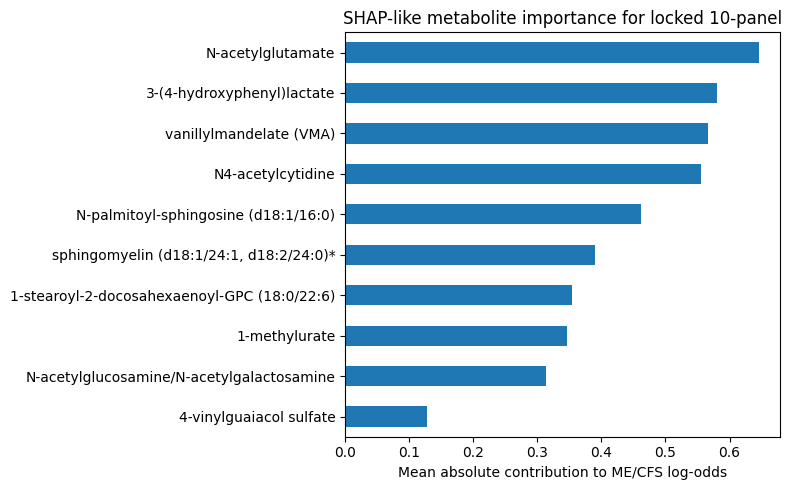

In [44]:
# =========================
# SHAP-STYLE CONTRIBUTION SCORES FOR LOGISTIC REGRESSION
# =========================
# For linear/logistic models, contribution = standardized metabolite value × coefficient

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get standardized values from final locked model
X_scaled = tradeoff_model.named_steps["scaler"].transform(
    X[TRADEOFF_FEATURES]
)

coefs = tradeoff_model.named_steps["logreg"].coef_[0]

# Contribution to log-odds for each subject/metabolite
contrib = X_scaled * coefs

shap_like_df = pd.DataFrame(
    contrib,
    columns=TRADEOFF_FEATURES
)

# Mean absolute contribution = global importance
global_importance = (
    shap_like_df
    .abs()
    .mean()
    .sort_values(ascending=False)
)

display(global_importance)

plt.figure(figsize=(8,5))
global_importance.sort_values().plot(kind="barh")
plt.xlabel("Mean absolute contribution to ME/CFS log-odds")
plt.title("SHAP-like metabolite importance for locked 10-panel")
plt.tight_layout()
plt.show()

In [47]:
print("Shape:", X[TRADEOFF_FEATURES].shape)

print("\nClass counts:")
print(y.value_counts())

print("\nMeans:")
display(
    X[TRADEOFF_FEATURES]
    .mean()
    .sort_index()
)

print("\nStds:")
display(
    X[TRADEOFF_FEATURES]
    .std()
    .sort_index()
)

Shape: (214, 10)

Class counts:
1    135
0     79
Name: study_ptorhc, dtype: int64

Means:


1-methylurate                                   0.872156
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)    1.334637
3-(4-hydroxyphenyl)lactate                      0.900319
4-vinylguaiacol sulfate                         0.258056
N-acetylglucosamine/N-acetylgalactosamine       0.797387
N-acetylglutamate                               0.545900
N-palmitoyl-sphingosine (d18:1/16:0)            1.262211
N4-acetylcytidine                               2.234001
sphingomyelin (d18:1/24:1, d18:2/24:0)*         1.218902
vanillylmandelate (VMA)                         1.258182
dtype: float64


Stds:


1-methylurate                                   1.243221
1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)    0.515241
3-(4-hydroxyphenyl)lactate                      0.321833
4-vinylguaiacol sulfate                         0.647525
N-acetylglucosamine/N-acetylgalactosamine       0.258585
N-acetylglutamate                               0.210872
N-palmitoyl-sphingosine (d18:1/16:0)            0.340849
N4-acetylcytidine                               1.484297
sphingomyelin (d18:1/24:1, d18:2/24:0)*         0.198900
vanillylmandelate (VMA)                         0.450444
dtype: float64

In [48]:
tradeoff_model.named_steps["logreg"].get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 5000,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 42,
 'solver': 'liblinear',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [64]:
# ==========================================
# NB1 FINAL EXPORT
# ==========================================

from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd().parent / "MECFS_FINAL_SIGNATURES"
NB1_DIR = ROOT / "NB1_LOCKED_10_PANEL"

NB1_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------
# Panel
# ------------------------------------------

pd.DataFrame({
    "feature": TRADEOFF_FEATURES
}).to_csv(
    NB1_DIR / "01_locked_10_metabolite_panel.csv",
    index=False
)

# ------------------------------------------
# Coefficients
# ------------------------------------------

coef_10.rename("coefficient").reset_index().rename(
    columns={"index": "feature"}
).to_csv(
    NB1_DIR / "02_10_metabolite_coefficients.csv",
    index=False
)

# ------------------------------------------
# Intercept
# ------------------------------------------

pd.DataFrame({
    "intercept": [intercept_10]
}).to_csv(
    NB1_DIR / "03_10_metabolite_intercept.csv",
    index=False
)

# ------------------------------------------
# Scaler constants
# ------------------------------------------

scaler_10 = tradeoff_model.named_steps["scaler"]

pd.DataFrame({
    "feature": TRADEOFF_FEATURES,
    "mean": scaler_10.mean_,
    "scale": scaler_10.scale_
}).to_csv(
    NB1_DIR / "04_10_metabolite_scaler_constants.csv",
    index=False
)

# ------------------------------------------
# Robustness
# ------------------------------------------

robustness_summary.to_csv(
    NB1_DIR / "05_10_metabolite_robustness.csv",
    index=False
)

# ------------------------------------------
# Permutation test
# ------------------------------------------

pd.DataFrame([{
    "real_auc": real_auc,
    "null_mean_auc": np.mean(perm_aucs),
    "null_std_auc": np.std(perm_aucs),
    "permutation_p": p_value
}]).to_csv(
    NB1_DIR / "06_10_metabolite_permutation_test.csv",
    index=False
)

print("Saved:")
print(NB1_DIR)

Saved:
c:\Users\rohan\OneDrive\Desktop\ME-CFS\src\MECFS_FINAL_SIGNATURES\NB1_LOCKED_10_PANEL


In [69]:
coef_from_model = pd.Series(
    tradeoff_model.named_steps["logreg"].coef_[0],
    index=TRADEOFF_FEATURES
)

coef_from_csv = pd.read_csv(
    NB1_DIR / "02_10_metabolite_coefficients.csv"
)

print(
    np.allclose(
        coef_from_model.values,
        coef_from_csv["coefficient"].values
    )
)

True


In [59]:
from sklearn.metrics import roc_auc_score
import numpy as np
probs = test_probs
def bootstrap_auc_ci(y_true, probs, n_boot=5000, seed=42):
    rng = np.random.default_rng(seed)

    y_true = np.array(y_true)
    probs = np.array(probs)

    aucs = []

    for _ in range(n_boot):
        idx = rng.choice(len(y_true), len(y_true), replace=True)

        if len(np.unique(y_true[idx])) < 2:
            continue

        aucs.append(
            roc_auc_score(y_true[idx], probs[idx])
        )

    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)

    return np.mean(aucs), lower, upper

auc_mean, auc_low, auc_high = bootstrap_auc_ci(y_test, probs)

print(f"AUC: {roc_auc_score(y_test, probs):.3f}")
print(f"Bootstrap mean: {auc_mean:.3f}")
print(f"95% CI: [{auc_low:.3f}, {auc_high:.3f}]")

AUC: 0.859
Bootstrap mean: 0.859
95% CI: [0.729, 0.954]


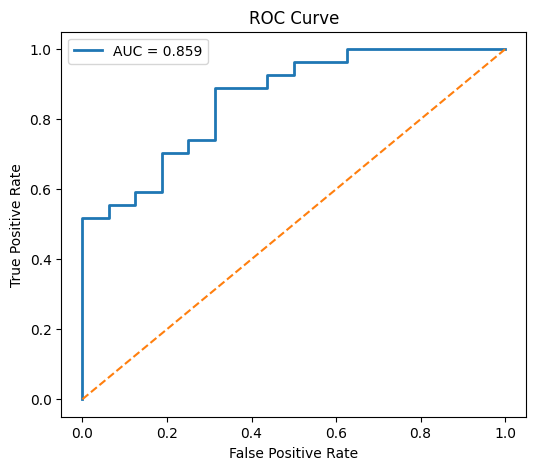

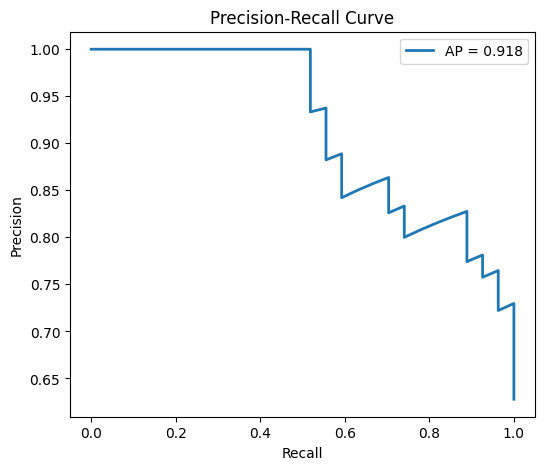

In [60]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# ROC

fpr, tpr, roc_thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# PR

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    probs
)

ap = average_precision_score(y_test, probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, lw=2,
         label=f"AP = {ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [61]:
from sklearn.metrics import confusion_matrix

# Youden's J

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)

optimal_threshold = roc_thresholds[best_idx]

y_pred = (probs >= optimal_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

ppv = tp / (tp + fp)
npv = tn / (tn + fn)

accuracy = (tp + tn) / (tp + tn + fp + fn)

balanced_accuracy = (
    sensitivity + specificity
) / 2

print(f"Optimal threshold: {optimal_threshold:.3f}")
print()

print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"PPV: {ppv:.3f}")
print(f"NPV: {npv:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Balanced accuracy: {balanced_accuracy:.3f}")
print()

print("Confusion matrix:")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

Optimal threshold: 0.581

Sensitivity: 0.889
Specificity: 0.688
PPV: 0.828
NPV: 0.786
Accuracy: 0.814
Balanced accuracy: 0.788

Confusion matrix:
TN=11, FP=5, FN=3, TP=24


In [62]:
import numpy as np
import pandas as pd

test_df = pd.DataFrame({
    "y_true": np.array(y_test),
    "prob_ME_CFS": np.array(probs)
})

print("Controls:")
print(test_df[test_df["y_true"] == 0]["prob_ME_CFS"].describe())

print("\nME/CFS:")
print(test_df[test_df["y_true"] == 1]["prob_ME_CFS"].describe())

print("\nHighest control probability:")
print(test_df[test_df["y_true"] == 0]["prob_ME_CFS"].max())

print("\nLowest ME/CFS probability:")
print(test_df[test_df["y_true"] == 1]["prob_ME_CFS"].min())

print("\nOptimal threshold used:")
print(optimal_threshold)

Controls:
count    16.000000
mean      0.375594
std       0.334702
min       0.015972
25%       0.061965
50%       0.264660
75%       0.689418
max       0.883579
Name: prob_ME_CFS, dtype: float64

ME/CFS:
count    27.000000
mean      0.789739
std       0.228434
min       0.157262
25%       0.670702
50%       0.890764
75%       0.959585
max       0.996077
Name: prob_ME_CFS, dtype: float64

Highest control probability:
0.8835785887636798

Lowest ME/CFS probability:
0.15726244151493465

Optimal threshold used:
0.5814597238843504


In [63]:
import numpy as np
import pandas as pd

score_df = pd.DataFrame({
    "y_true": np.array(y_test),
    "prob_ME_CFS": np.array(probs)
})

thresholds = np.arange(0.1, 1.0, 0.05)

rows = []

for low_cut in thresholds:
    for high_cut in thresholds:
        if low_cut >= high_cut:
            continue

        called_low = score_df["prob_ME_CFS"] < low_cut
        called_high = score_df["prob_ME_CFS"] > high_cut
        inconclusive = ~(called_low | called_high)

        low_group = score_df[called_low]
        high_group = score_df[called_high]

        low_correct = (low_group["y_true"] == 0).mean() if len(low_group) > 0 else np.nan
        high_correct = (high_group["y_true"] == 1).mean() if len(high_group) > 0 else np.nan

        rows.append({
            "low_cut": low_cut,
            "high_cut": high_cut,
            "n_low_called": len(low_group),
            "n_high_called": len(high_group),
            "n_inconclusive": inconclusive.sum(),
            "low_correct_rate": low_correct,
            "high_correct_rate": high_correct,
            "coverage": 1 - inconclusive.mean()
        })

range_df = pd.DataFrame(rows)

range_df.sort_values(
    ["high_correct_rate", "low_correct_rate", "coverage"],
    ascending=False
).head(20)

,low_cut,high_cut,n_low_called,n_high_called,n_inconclusive,low_correct_rate,high_correct_rate,coverage
31,0.15,0.90,6,13,24,1.000000,1.0,0.441860
15,0.10,0.90,5,13,25,1.000000,1.0,0.418605
32,0.15,0.95,6,7,30,1.000000,1.0,0.302326
16,0.10,0.95,5,7,31,1.000000,1.0,0.279070
46,0.20,0.90,8,13,22,0.875000,1.0,0.488372
60,0.25,0.90,8,13,22,0.875000,1.0,0.488372
47,0.20,0.95,8,7,28,0.875000,1.0,0.348837
61,0.25,0.95,8,7,28,0.875000,1.0,0.348837
73,0.30,0.90,11,13,19,0.818182,1.0,0.558140
85,0.35,0.90,11,13,19,0.818182,1.0,0.558140
